In [1]:
import pandas as pd
import numpy as np
import torch

In [1]:
# Cell 3: ConditionalVAE (loss_function MODIFIED)
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List, Tuple

class ConditionalVAE(nn.Module):
    def __init__(self,
                 in_channels: int = 1,
                 loc_channels: int = 2,
                 mask_channels: int = 1,
                 latent_dim: int = 16,
                 hidden_dims: List[int] = [32, 64, 128, 256, 512],
                 img_size: int = 40):
        super().__init__()

        self.latent_dim = latent_dim
        self.img_size = img_size
        self.in_channels = in_channels
        self.loc_channels = loc_channels
        self.mask_channels = mask_channels

        # ---------------- Encoder ----------------
        enc_in_channels = in_channels + loc_channels + mask_channels
        self.hidden_dims_enc = hidden_dims
        modules = []
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(enc_in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU()
                )
            )
            enc_in_channels = h_dim
        self.encoder = nn.Sequential(*modules)

        # Compute encoder output sizes dynamically
        encoder_sizes = self.compute_encoder_sizes(img_size, hidden_dims)
        self.final_spatial = encoder_sizes[-1]
        flat_size = hidden_dims[-1] * self.final_spatial**2

        # Latent space
        self.fc_mu = nn.Linear(flat_size, latent_dim)
        self.fc_var = nn.Linear(flat_size, latent_dim)

        # ---------------- Decoder ----------------
        self.decoder_input = nn.Linear(
            latent_dim + (loc_channels + mask_channels) * img_size * img_size,
            flat_size
        )

        self.hidden_dims_dec = hidden_dims[::-1]

        dec_modules = []
        for i in range(len(self.hidden_dims_dec) - 1):
            dec_modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        self.hidden_dims_dec[i],
                        self.hidden_dims_dec[i+1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=0  # always 0, we will pad later
                    ),
                    nn.BatchNorm2d(self.hidden_dims_dec[i+1]),
                    nn.LeakyReLU()
                )
            )
        self.decoder = nn.Sequential(*dec_modules)

        self.final_mu = nn.Conv2d(self.hidden_dims_dec[-1], out_channels=in_channels, kernel_size=3, padding=1)
        self.final_logvar = nn.Conv2d(self.hidden_dims_dec[-1], out_channels=in_channels, kernel_size=3, padding=1)

    # ---------------- Static methods ----------------
    @staticmethod
    def compute_encoder_sizes(img_size, hidden_dims, kernel_size=3, stride=2, padding=1):
        sizes = []
        size = img_size
        for _ in hidden_dims:
            size = (size + 2*padding - kernel_size) // stride + 1
            sizes.append(size)
        return sizes

    # ---------------- Forward methods ----------------
    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        result = self.encoder(x)
        result = torch.flatten(result, start_dim=1)
        mu = self.fc_mu(result)
        log_var = self.fc_var(result)
        return mu, log_var

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps * std + mu

    def decode(self, z: torch.Tensor, loc_mask: torch.Tensor, meas_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # Combine conditioning info
        cond = torch.cat([loc_mask, meas_mask], dim=1)
        cond_flat = cond.view(cond.size(0), -1)
        dec_input = torch.cat([z, cond_flat], dim=1)

        result = self.decoder_input(dec_input)
        result = result.view(-1, self.hidden_dims_dec[0], self.final_spatial, self.final_spatial)
        result = self.decoder(result)

        # Zero-pad to ensure output is img_size x img_size
        _, _, h, w = result.shape
        pad_h = self.img_size - h
        pad_w = self.img_size - w
        if pad_h > 0 or pad_w > 0:
            # pad = (left, right, top, bottom)
            result = F.pad(result, (0, pad_w, 0, pad_h))

        mu_pred = self.final_mu(result)
        logvar_pred = torch.clamp(self.final_logvar(result), -10, 10)
        return mu_pred, logvar_pred

    def forward(self, x: torch.Tensor, loc_mask: torch.Tensor, meas_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        # Tile location mask if needed
        if loc_mask.dim() == 3:
            loc_mask = loc_mask.unsqueeze(0).repeat(x.size(0), 1, 1, 1)

        enc_in = torch.cat([x, loc_mask, meas_mask], dim=1)
        mu, log_var = self.encode(enc_in)
        z = self.reparameterize(mu, log_var)
        mu_pred, logvar_pred = self.decode(z, loc_mask, meas_mask)
        return mu_pred, logvar_pred, mu, log_var

    # ---------------- Loss function ----------------
    # --- MODIFIED to accept valid_mask ---
    def loss_function(self, x: torch.Tensor, mu_pred: torch.Tensor, logvar_pred: torch.Tensor,
                      mu: torch.Tensor, log_var: torch.Tensor, valid_mask: torch.Tensor, 
                      kld_weight: float = 1e-3) -> dict:
        
        const = torch.log(torch.tensor(2.0 * torch.pi, device=x.device))
        recon_var = torch.exp(logvar_pred)
        nll_element = 0.5 * ((x - mu_pred)**2 / recon_var + logvar_pred + const)

        # --- MODIFICATION: Apply valid_mask ---
        # valid_mask is [1, 1, H, W], nll_element is [B, 1, H, W]
        # Broadcasting will apply the mask to every sample in the batch
        nll_element_masked = nll_element * valid_mask
        
        # Get total NLL sum over all valid pixels in the batch
        total_nll_sum = torch.sum(nll_element_masked)
        
        # Get total number of valid pixels in the batch
        num_valid_per_sample = torch.sum(valid_mask)
        batch_size = x.size(0)
        total_valid_count = num_valid_per_sample * batch_size

        # Calculate mean NLL, handling potential division by zero
        if total_valid_count > 0:
            nll_loss = total_nll_sum / total_valid_count
        else:
            # If no valid pixels, set NLL loss to 0
            nll_loss = torch.tensor(0.0, device=x.device, requires_grad=True)
        # --- End MODIFICATION ---

        kld_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1))
        total_loss = nll_loss + kld_weight * kld_loss
        return {"loss": total_loss, "NLL": nll_loss, "KLD": kld_loss}

In [ ]:
""" import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

 # -----------------------------
# 1️⃣ Load CSVs
# -----------------------------
df_coords = pd.read_csv("original_1600_grid_points.csv")
df_valid = pd.read_csv("inside.csv", header=None, names=['X','Y'])
df_measurements = pd.read_csv("combined_sinr.csv")  # 30 × 7700

H, W = 40, 40

# -----------------------------
# 2️⃣ Coordinates → Grid Indices
# -----------------------------
def coords_to_indices(df, H, W):
    x_vals = df['X'].values
    y_vals = df['Y'].values

    x_norm = (x_vals - x_vals.min()) / (x_vals.max() - x_vals.min())
    y_norm = (y_vals - y_vals.min()) / (y_vals.max() - y_vals.min())

    x_idx = np.clip((x_norm * (W-1)).astype(int), 0, W-1)
    y_idx = np.clip((y_norm * (H-1)).astype(int), 0, H-1)

    return np.stack([y_idx, x_idx], axis=1)

# Valid region mask
valid_indices = coords_to_indices(df_valid, H, W)

# Sensor measurement points (30 sensors)
measurement_indices = coords_to_indices(df_measurements[['X','Y']], H, W)
measurement_indices = np.array(measurement_indices)

# -----------------------------
# 3️⃣ Create Valid Mask with 8-neighbor hole filling
# -----------------------------
valid_mask = torch.zeros((H, W), dtype=torch.bool)
valid_mask[valid_indices[:,0], valid_indices[:,1]] = True

def fill_holes_8_neighbors(mask_np):
    H, W = mask_np.shape
    new_mask = mask_np.copy()

    for y in range(1, H - 1):
        for x in range(1, W - 1):
            if mask_np[y, x] == 0:
                region = mask_np[y-1:y+2, x-1:x+2]
                if np.sum(region) == 8:
                    new_mask[y, x] = 1
    return new_mask

valid_mask_np = valid_mask.numpy().astype(np.uint8)
valid_mask_filled = fill_holes_8_neighbors(valid_mask_np)
valid_mask = torch.tensor(valid_mask_filled, dtype=torch.bool)
valid_coords_mask = valid_mask.unsqueeze(0).unsqueeze(0).float()  # (1,1,H,W)
print("✅ Valid mask created with 8-neighbor hole filling") 

# -----------------------------
# 4️⃣ Create Measurement Mask
# -----------------------------
meas_mask = torch.zeros((H, W), dtype=torch.bool)
meas_mask[measurement_indices[:,0], measurement_indices[:,1]] = True
meas_coords_mask = meas_mask.unsqueeze(0).unsqueeze(0).float()  # (1,1,H,W)

# -----------------------------
# 5️⃣ Extract SINR samples (30 × 7700)
# -----------------------------
data_array = df_measurements.iloc[:, 2:].values.astype(np.float32)
num_sensors, num_samples = data_array.shape

# -----------------------------
# 6️⃣ Fill the (samples, 40, 40) grid
# -----------------------------
grid = np.zeros((num_samples, H, W), dtype=np.float32)
for idx, (r, c) in enumerate(measurement_indices):
    grid[:, r, c] = data_array[idx]

# Final X_data shape = (num_samples, 1, H, W)
X_data = torch.tensor(grid).unsqueeze(1).float()
print("Final X_data:", X_data.shape)

# -----------------------------
# 7️⃣ Validation coordinates (10 sensors)
# -----------------------------
val_indices = [3, 6, 25, 12, 13, 17, 19, 21, 10, 2]
val_coords = measurement_indices[val_indices]
print("Validation coord grid positions:\n", val_coords)

val_coords_y = torch.tensor(val_coords[:, 0], dtype=torch.long)
val_coords_x = torch.tensor(val_coords[:, 1], dtype=torch.long)

# Train coordinates = all except validation set
train_mask = np.ones(len(measurement_indices), dtype=bool)
train_coords = measurement_indices[train_mask]

train_coords_y = torch.tensor(train_coords[:, 0], dtype=torch.long)
train_coords_x = torch.tensor(train_coords[:, 1], dtype=torch.long)
num_train_locs = len(train_coords)
print("Train sensors:", num_train_locs)
 """

✅ Valid mask created with 8-neighbor hole filling
Final X_data: torch.Size([7749, 1, 40, 40])
Validation coord grid positions:
 [[15  5]
 [29  7]
 [28 28]
 [14 12]
 [39 12]
 [14 19]
 [39 21]
 [20 23]
 [ 0 12]
 [13  3]]
Train sensors: 30


✅ Valid mask created (Exact Mapping + Binary Hole Filling)
Final X_data shape: torch.Size([7749, 1, 40, 40])
Total Sensors: 30
Training Sensors: 30
Validation Sensors: 10


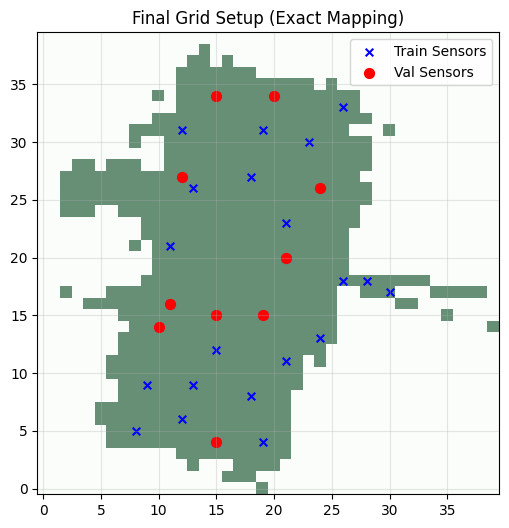

In [4]:
import pandas as pd
import numpy as np
import torch
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Load CSVs
# -----------------------------
# Master grid definitions
df_coords = pd.read_csv("original_1600_grid_points.csv")

# Valid region (floor plan)
df_valid = pd.read_csv("inside.csv", header=None, names=['X', 'Y'])

# Measurement data (Sensors)
df_measurements = pd.read_csv("combined_sinr.csv")  # Expected: 30 rows x 7702 cols (X, Y, samples...)

H, W = 40, 40

# -----------------------------
# 2️⃣ Create Exact Index Mapping (The Fix)
# -----------------------------
# Instead of normalizing (which causes rounding errors), we map unique values to 0..39
unique_x = np.sort(df_coords['x'].unique())
unique_y = np.sort(df_coords['y'].unique())

if len(unique_x) != W or len(unique_y) != H:
    print(f"⚠️ Warning: Grid size mismatch! Found {len(unique_x)}x{len(unique_y)} unique coords.")

# Create lookup dictionaries: { coordinate_value : index }
x_map = {val: i for i, val in enumerate(unique_x)}
y_map = {val: i for i, val in enumerate(unique_y)}

def get_indices_from_df(df, col_x='X', col_y='Y'):
    """Maps physical coordinates to grid indices using the exact lookup map."""
    try:
        x_idx = df[col_x].map(x_map).astype(int).values
        y_idx = df[col_y].map(y_map).astype(int).values
        return np.stack([y_idx, x_idx], axis=1)
    except ValueError as e:
        print(f"❌ Error: DataFrame contains coordinates not found in the master grid.")
        raise e

# -----------------------------
# 3️⃣ Create Valid Mask (with Robust Hole Filling)
# -----------------------------
# Get indices for the valid region
valid_indices = get_indices_from_df(df_valid)

# Create initial boolean mask
valid_mask_np = np.zeros((H, W), dtype=bool)
valid_mask_np[valid_indices[:, 0], valid_indices[:, 1]] = True

# Apply Binary Hole Filling (Fixes the white dots safely)
valid_mask_filled = ndimage.binary_fill_holes(valid_mask_np)

# Convert to Tensor
valid_mask = torch.tensor(valid_mask_filled, dtype=torch.bool)
valid_coords_mask = valid_mask.unsqueeze(0).unsqueeze(0).float()  # (1, 1, H, W)

print("✅ Valid mask created (Exact Mapping + Binary Hole Filling)")

# -----------------------------
# 4️⃣ Process Sensor Measurements
# -----------------------------
# Map sensor coordinates to indices
measurement_indices = get_indices_from_df(df_measurements[['X', 'Y']])

# Create Measurement Mask
meas_mask = torch.zeros((H, W), dtype=torch.bool)
meas_mask[measurement_indices[:, 0], measurement_indices[:, 1]] = True
meas_coords_mask = meas_mask.unsqueeze(0).unsqueeze(0).float()

# -----------------------------
# 5️⃣ Extract SINR Data & Fill Grid
# -----------------------------
# Assuming first 2 cols are X,Y and the rest are samples
data_array = df_measurements.iloc[:, 2:].values.astype(np.float32)
num_sensors, num_samples = data_array.shape

# Create empty grid: (Samples, H, W)
grid = np.zeros((num_samples, H, W), dtype=np.float32)

# Fill the grid at the specific sensor locations
for idx, (r, c) in enumerate(measurement_indices):
    grid[:, r, c] = data_array[idx]  # data_array[idx] is shape (num_samples,)

# Final Data Tensor: (Samples, 1, H, W)
X_data = torch.tensor(grid).unsqueeze(1).float()
print(f"Final X_data shape: {X_data.shape}")

# -----------------------------
# 6️⃣ Split Train / Validation Sensors
# -----------------------------
val_sensor_indices = [3, 6, 25, 12, 13, 17, 19, 21, 10, 2]

# Get grid coordinates for validation sensors
val_coords = measurement_indices[val_sensor_indices]
val_coords_y = torch.tensor(val_coords[:, 0], dtype=torch.long)
val_coords_x = torch.tensor(val_coords[:, 1], dtype=torch.long)

# Create Train Mask (All sensors EXCEPT validation ones)
train_mask = np.ones(num_sensors, dtype=bool)


# Get grid coordinates for training sensors
train_coords = measurement_indices[train_mask]
train_coords_y = torch.tensor(train_coords[:, 0], dtype=torch.long)
train_coords_x = torch.tensor(train_coords[:, 1], dtype=torch.long)

print(f"Total Sensors: {num_sensors}")
print(f"Training Sensors: {len(train_coords)}")
print(f"Validation Sensors: {len(val_coords)}")

# -----------------------------
# 7️⃣ Visualization Check
# -----------------------------
plt.figure(figsize=(6, 6))
plt.imshow(valid_mask.numpy(), origin='lower', cmap='Greens', alpha=0.6, label='Valid Region')
plt.scatter(train_coords[:, 1], train_coords[:, 0], c='blue', s=30, label='Train Sensors', marker='x')
plt.scatter(val_coords[:, 1], val_coords[:, 0], c='red', s=50, label='Val Sensors', marker='o')
plt.title("Final Grid Setup (Exact Mapping)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

Edits to do: dont standardise for whole dataset, standardise by sample from train data only, leave val normally, so that in prediction, i take a sample, i normalise it by sample and then do the prediction and denormalise using the same values to map it back, so that i have my ground truth in normal scale only

In [5]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

# -----------------------------
# 1️⃣ Split dataset
# -----------------------------
dataset = TensorDataset(X_data)

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

# -----------------------------
# 2️⃣ Stack all training samples into one tensor (B, H, W)
# -----------------------------
train_stack = torch.stack([x[0] for x in train_data], dim=0)  # shape: (B_train, H, W)
train_stack = train_stack.squeeze(1)  # if channel dim exists, now (B_train, H, W)

# -----------------------------
# 3️⃣ Compute per-sensor mean/std using meas_mask
# -----------------------------
# meas_mask shape should be (1, H, W)
meas_mask_bool = meas_mask.bool().squeeze(0)  # shape (H, W)

# Extract measured points across all samples
meas_vals = train_stack[:, meas_mask_bool]  # shape: (B_train, N_meas)

# Compute mean/std per sensor location
sensor_mean = meas_vals.mean(dim=0)  # shape: (N_meas,)
sensor_std  = meas_vals.std(dim=0) + 1e-8  # avoid division by zero

# -----------------------------
# 4️⃣ Normalize all training samples
# -----------------------------
train_norm_list = []

for (x,) in train_data:
    x_np = x.clone().squeeze(0)  # (H, W)
    
    # Apply per-sensor normalization to valid points
    x_meas_vals = x_np[meas_mask_bool]
    x_np[meas_mask_bool] = (x_meas_vals - sensor_mean) / sensor_std
    
    
    train_norm_list.append((x_np.unsqueeze(0),))

# -----------------------------
# 5️⃣ Create DataLoaders
# -----------------------------
train_loader = DataLoader(train_norm_list, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=8, shuffle=False)


In [ ]:
from torch.optim import Adam
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConditionalVAE(
    in_channels=1,
    loc_channels=2,
    mask_channels=1,
    latent_dim=16,
    img_size=H,
    hidden_dims=[32,64,128,256,512]
).to(device)

optimizer = Adam(model.parameters(), lr=1e-3)
epochs = 100


In [7]:
# Build loc_mask_base (H × W × 2)
yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")

loc_x = (xx.float() / (W-1)).unsqueeze(0)  # (1,H,W)
loc_y = (yy.float() / (H-1)).unsqueeze(0)  # (1,H,W)

loc_mask_base = torch.cat([loc_x, loc_y], dim=0).unsqueeze(0)  # (1,2,H,W)


In [8]:
valid_coords_mask = valid_coords_mask.to(device)
loc_mask_base = loc_mask_base.to(device)
val_coords_y = val_coords_y.to(device)
val_coords_x = val_coords_x.to(device)
train_coords_y = train_coords_y.to(device)
train_coords_x = train_coords_x.to(device)

k_choices = torch.tensor([10, 15, 20, 25]).to(device)
k_probs   = torch.tensor([0.6, 0.133, 0.133, 0.133]).to(device)


In [75]:

from tqdm import tqdm
def get_beta(epoch, max_epochs, warmup_epochs=10, final_beta=1.0):
    if epoch < warmup_epochs:
        return 0.0
    progress = (epoch - warmup_epochs) / (max_epochs - warmup_epochs)
    return min(final_beta, final_beta * progress)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    beta = get_beta(epoch, epochs)

    for (x_batch,) in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        x_batch = x_batch.to(device)
        B = x_batch.size(0)

        # 1. LOC mask
        loc_batch = loc_mask_base.repeat(B, 1, 1, 1)

        # 2. Random K sensors
        mask_batch = torch.zeros(B, 1, H, W, device=device)

        k_idx = torch.multinomial(k_probs, num_samples=B, replacement=True)
        k_vals = k_choices[k_idx]

        for i in range(B):
            k = k_vals[i].item()
            idx = torch.randperm(num_train_locs, device=device)[:k]
            y = train_coords_y[idx]
            x = train_coords_x[idx]
            mask_batch[i, 0, y, x] = 1.0

        # 3. Mask encoder input
        x_input = x_batch * mask_batch

        optimizer.zero_grad()

        mu_pred, logvar_pred, mu, log_var = model(x_input, loc_batch, mask_batch)

        losses = model.loss_function(
            x_batch, mu_pred, logvar_pred, mu, log_var,
            valid_mask=valid_coords_mask,
            kld_weight=beta
        )
        
        loss = losses["loss"]
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * B

    # ----------------------
    # VALIDATION
    # ----------------------
    model.eval()
    val_loss = 0.0

    # fixed 10-sensor mask
    val_mask = torch.zeros(1,1,H,W, device=device)
    val_mask[0,0,val_coords_y, val_coords_x] = 1.0

    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            B = x_batch.size(0)
            x_norm = torch.zeros_like(x_batch)
            # Extract the raw (unnormalized) sensor values
            sensor_vals = x_batch[:, 0, val_coords_y, val_coords_x].cpu().numpy()

            # Compute mean/std for each of the 10 measured sensor points
            sensor_means = sensor_vals.mean(axis = 0)
            sensor_stds  = sensor_vals.std(axis = 0) + 1e-8
            # Normalize only the measured sensor points
            norm_vals = (sensor_vals - sensor_means) / sensor_stds
            x_norm[:, 0, val_coords_y, val_coords_x] = torch.tensor(norm_vals, dtype=torch.float32)
            loc_batch = loc_mask_base.repeat(B, 1, 1, 1)
            mask_batch = val_mask.repeat(B, 1, 1, 1)

            x_input = x_norm * mask_batch

            mu_pred, logvar_pred, mu, log_var = model(x_input, loc_batch, mask_batch)

            losses = model.loss_function(
                x_batch, mu_pred, logvar_pred, mu, log_var,
                valid_mask=valid_coords_mask,
                kld_weight=1e-3
            )

            val_loss += losses["loss"].item() * B

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}] | Train {train_loss:.4f} | Val {val_loss:.4f}")

print("Training complete!")
torch.save(model.state_dict(), "conditional_vae_model1.pth")
print("Model saved to 'conditional_vae_model1.pth'")



Epoch [1/10] | Train 85.8508 | Val 256.8119


KeyboardInterrupt: 

In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ✅ 第一步：加载训练好的模型
device = torch.device("cpu")
#device = torch.device("cuda")

model = ConditionalVAE(
    in_channels=1,
    loc_channels=2,
    mask_channels=1,
    latent_dim=16,
    img_size=H,
    hidden_dims=[32,64,128,256,512]
).to(device)

model.load_state_dict(torch.load("conditional_vae_model.pth",map_location=torch.device('cpu')))
#model.load_state_dict(torch.load("conditional_vae_model.pth",map_location=torch.device('cuda')))
print("✅ Model loaded from 'conditional_vae_model.pth'")

model.eval()

✅ Model loaded from 'conditional_vae_model.pth'


ConditionalVAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (4)

In [18]:
# ================================================================
# NEW BLOCK: Compute mean/std for 10 sensors → IDW → denormalize
# ================================================================
x_batch, = next(iter(val_loader))
x_batch = x_batch.to(device)
B = x_batch.size(0)

val_mask = torch.zeros(1, 1, H, W, device=device)
val_mask[0, 0, val_coords_y, val_coords_x] = 1.0
mask_batch = val_mask.expand(B, -1, -1, -1)
x_input = x_batch * mask_batch
print("🔄 Computing mean/std for the 10 validation sensors...")

# Extract the raw (unnormalized) sensor values
sensor_vals = x_batch[:, 0, val_coords_y, val_coords_x].cpu().numpy()

# Compute mean/std for each of the 10 measured sensor points
sensor_means = sensor_vals.mean(axis = 0)
sensor_stds  = sensor_vals.std(axis = 0) + 1e-8

# Per-sensor statistics (shape=10)
#sensor_means = np.full(len(sensor_vals), sensor_mean)
#sensor_stds  = np.full(len(sensor_vals), sensor_std)

print("✔ Sensor mean/std computed")
#print(f"   mean={sensor_mean:.4f}, std={sensor_std:.4f}")

# ================================================================
# IDW to interpolate mean/std to all 650 valid grid points
# ================================================================

print("🌐 Performing IDW interpolation to 650 valid points...")

valid_y, valid_x = valid_mask.nonzero(as_tuple=True)
valid_xy = np.stack([valid_y.cpu().numpy(), valid_x.cpu().numpy()], axis=1)

sensor_xy = np.stack([val_coords_y.cpu().numpy(), val_coords_x.cpu().numpy()], axis=1)

def idw_interpolate(sensor_xy, sensor_vals, query_xy, power=2):
    """Inverse Distance Weighting interpolation."""
    interpolated = []
    for q in query_xy:
        d = np.sqrt(((sensor_xy - q)**2).sum(axis=1))
        d = np.maximum(d, 1e-6)  # avoid div by zero
        w = 1 / (d**power)
        w /= w.sum()
        interpolated.append(np.sum(w * sensor_vals))
    return np.array(interpolated)

# IDW interpolate mean and std over 650 valid grid points
interp_mean_650 = idw_interpolate(sensor_xy, sensor_means, valid_xy)
interp_std_650  = idw_interpolate(sensor_xy, sensor_stds,  valid_xy)

print("✔ IDW interpolation complete")

# ================================================================
# Normalize input grid using IDW-interpolated mean/std
# ================================================================

print("🔧 Normalizing input grid using IDW statistics...")

x_input = torch.zeros_like(x_batch)

# Normalize only the measured sensor points
norm_vals = (sensor_vals - sensor_means) / sensor_stds
x_input[:, 0, val_coords_y, val_coords_x] = torch.tensor(norm_vals, dtype=torch.float32)

x_input = x_input.to(device)

print("✔ Input normalized and ready for model")

# ================================================================
# Run model prediction
# ================================================================

with torch.no_grad(): 
    mu_pred, logvar_pred, _, _ = model(
        x_input,
        loc_mask_base.repeat(B, 1, 1, 1),
        mask_batch
    )

std_pred = torch.exp(0.5 * logvar_pred)
sampled_pred = mu_pred + std_pred * torch.randn_like(std_pred)

print("✔ Model forward pass completed")

# ================================================================
# De-normalize predictions and ground truth using IDW stats
# ================================================================

print("🔄 De-normalizing predictions and GT using IDW mean/std...")

# Predicted normalized values at valid grid points
pred_norm_vals = sampled_pred[7, 0, valid_y, valid_x].cpu().numpy()

# De-normalize using IDW-interpolated stats
pred_vals_orig = pred_norm_vals * interp_std_650 + interp_mean_650

# Ground truth at valid points (unnormalized from loader)
gt_vals = x_input[7, 0, valid_y, valid_x].cpu().numpy()

# De-normalize GT using IDW stats
gt_vals_orig = gt_vals * interp_std_650 + interp_mean_650

print("✔ De-normalization done")


🔄 Computing mean/std for the 10 validation sensors...
✔ Sensor mean/std computed
🌐 Performing IDW interpolation to 650 valid points...
✔ IDW interpolation complete
🔧 Normalizing input grid using IDW statistics...
✔ Input normalized and ready for model
✔ Model forward pass completed
🔄 De-normalizing predictions and GT using IDW mean/std...
✔ De-normalization done


C:\Users\suram\AppData\Local\Temp\ipykernel_18660\2243350276.py:18: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\suram\anaconda3\envs\pytor_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


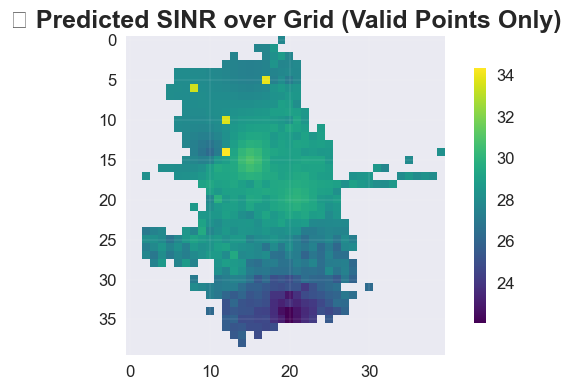

C:\Users\suram\AppData\Local\Temp\ipykernel_18660\2243350276.py:18: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\suram\anaconda3\envs\pytor_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


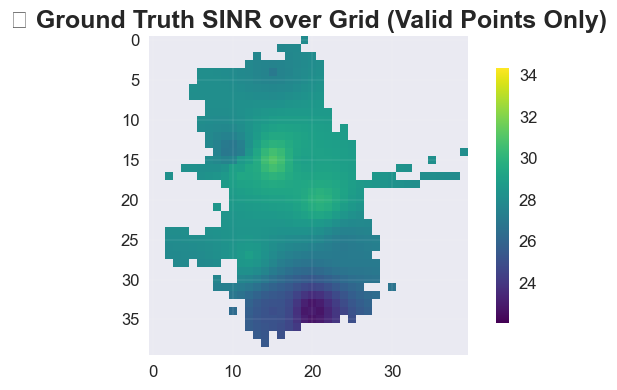

C:\Users\suram\AppData\Local\Temp\ipykernel_18660\2243350276.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\suram\anaconda3\envs\pytor_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


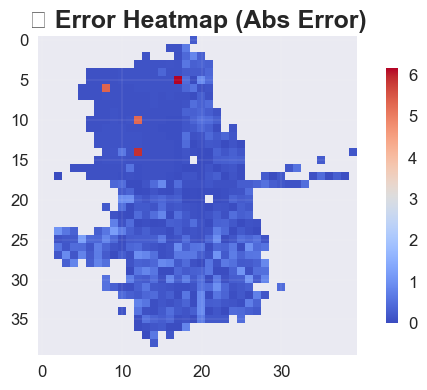


🎉 Visualization Complete!


In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

# ==========================================================
# Utility function for nicer plots
# ==========================================================
def plot_grid(data, title, cmap="viridis", vmin=None, vmax=None):
    plt.figure(figsize=(6, 4))
    plt.imshow(data, cmap=cmap, aspect="equal", vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(shrink=0.8)
    cbar.ax.tick_params(labelsize=12)
    plt.title(title, fontsize=18, fontweight="bold")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color="white", linewidth=0.3, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==========================================================
# Build full grids (H × W) for plotting
# ==========================================================
pred_full_grid = np.zeros((H, W), dtype=np.float32)
gt_full_grid   = np.zeros((H, W), dtype=np.float32)

# Fill valid locations
valid_y, valid_x = valid_mask.nonzero(as_tuple=True)
valid_y_cpu = valid_y.cpu().numpy()
valid_x_cpu = valid_x.cpu().numpy()
pred_full_grid[valid_y_cpu, valid_x_cpu] = pred_vals_orig
gt_full_grid[valid_y_cpu, valid_x_cpu]   = gt_vals_orig

# Mask zeros (invalid)
masked_pred = np.ma.masked_where(pred_full_grid == 0, pred_full_grid)
masked_gt   = np.ma.masked_where(gt_full_grid == 0, gt_full_grid)

# Shared color scale for fairness
cmin = min(pred_vals_orig.min(), gt_vals_orig.min())
cmax = max(pred_vals_orig.max(), gt_vals_orig.max())
#cmin = 15
#cmax = 30


# ==========================================================
# 1️⃣ Predicted SINR (full grid)
# ==========================================================
plot_grid(
    masked_pred,
    title="📡 Predicted SINR over Grid (Valid Points Only)",
    cmap="viridis",
    vmin=cmin,
    vmax=cmax
)


# ==========================================================
# 2️⃣ Ground Truth SINR (full grid)
# ==========================================================
plot_grid(
    masked_gt,
    title="🎯 Ground Truth SINR over Grid (Valid Points Only)",
    cmap="viridis",
    vmin=cmin,
    vmax=cmax
)


# ==========================================================
# 3️⃣ Error heatmap
# ==========================================================
error_grid = np.abs(pred_full_grid - gt_full_grid)
masked_error = np.ma.masked_where(error_grid == 0, error_grid)

plot_grid(
    masked_error,
    title="❌ Error Heatmap (Abs Error)",
    cmap="coolwarm",
    vmin=0,
    vmax=masked_error.max()
)

print("\n🎉 Visualization Complete!")


c:\Users\suram\anaconda3\envs\pytor_env\lib\site-packages\matplotlib\cbook.py:1719: UserWarning: Warning: converting a masked element to nan.
  return math.isfinite(val)


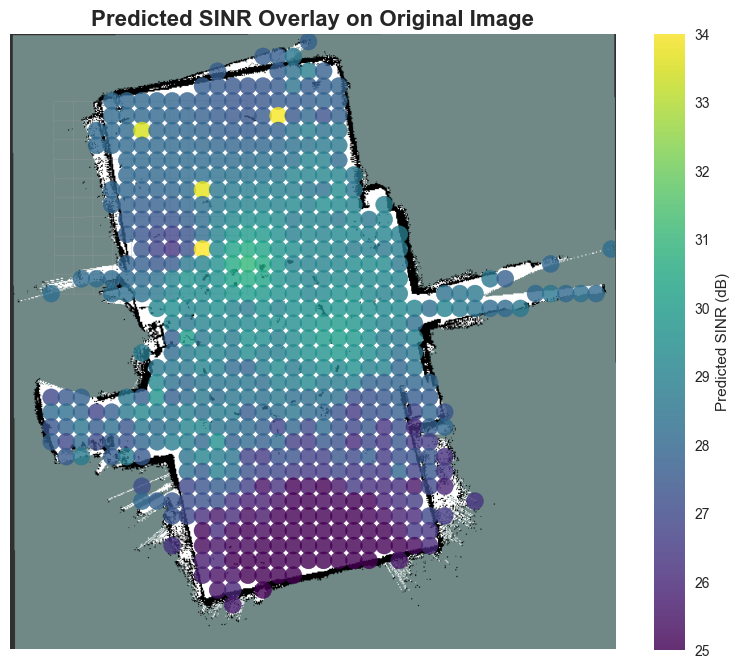

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Load original image
# -----------------------------
img = plt.imread("map_of_R1_Hall.png")
H_img, W_img = img.shape[:2]

# -----------------------------
# Original 1600 grid coordinates from CSV
# -----------------------------
orig_coords = df_coords[['x','y']].values  # shape (1600,2)
x_min, x_max = orig_coords[:,0].min(), orig_coords[:,0].max()
y_min, y_max = orig_coords[:,1].min(), orig_coords[:,1].max()

# -----------------------------
# 40x40 prediction grid
# -----------------------------
H_grid, W_grid = masked_pred.shape

# -----------------------------
# Reverse mapping: grid index -> pixel coordinates
# -----------------------------
pixel_x = x_min + (x_max - x_min) * (np.arange(W_grid) / (W_grid-1))
pixel_y = y_min + (y_max - y_min) * (np.arange(H_grid) / (H_grid-1))
grid_X, grid_Y = np.meshgrid(pixel_x, pixel_y)  # shape (H_grid, W_grid)

# Flatten for plotting
grid_X_flat = grid_X.flatten()
grid_Y_flat = grid_Y.flatten()
pred_flat   = pred_full_grid.flatten()

# -----------------------------
# Mask zeros to display as white
# -----------------------------
pred_masked = np.ma.masked_where(pred_flat == 0, pred_flat)

# -----------------------------
# Plot overlay
# -----------------------------
plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis('off')

# Use scatter; masked points will be white
sc = plt.scatter(grid_X_flat, grid_Y_flat, c=pred_masked, cmap='viridis', s=150, alpha=0.8, vmin=25, vmax=34)
plt.colorbar(sc, label='Predicted SINR (dB)')
plt.title('Predicted SINR Overlay on Original Image', fontsize=16, fontweight='bold')
plt.show()


In [43]:
pred_full_grid.shape

(40, 40)